# The phase diagram of nitrogen &mdash; the same calculation, different choices

This is the companion to `CO2_phases.ipynb`. **Read that one first**: it sets up the Antoine,
Clausius&ndash;Clapeyron, and Clapeyron relations of Section 7.7 and builds a $P$&ndash;$T$
diagram with them. Everything here uses the same three relations.

The point of doing it twice is not repetition. At two places the calculation needs a number the
data do not hand you directly, and this notebook makes the **opposite choice** from the CO$_2$
one at both:

| | `CO2_phases.ipynb` | this notebook |
|---|---|---|
| $\Delta_\mathrm{fus}\underline V$ for the melting line | from solid and liquid **densities** | by **inverting the Clapeyron equation** between two known points on the melting line |
| anchor for the vaporization curve | the **triple point**, integrating up | the **critical point**, integrating down |

Neither choice is more correct in principle. What happens when you try
them: **the second method looks more elegant and is far worse**, and the reason has nothing to
do with thermodynamics. Know why before you reach for the same trick on your own
data.

Nitrogen is also a useful contrast to CO$_2$ physically. Its triple point is at **0.125 bar**,
*below* atmospheric, so nitrogen has an ordinary liquid range at 1 atm &mdash; you can pour it
&mdash; and its normal boiling point, 77.4 K, is one of the most-used temperatures in the
laboratory. CO$_2$, whose triple point is at 5.18 bar, has no liquid state at atmospheric
pressure at all. Same diagram, same relations, opposite everyday behavior, and the whole
difference is where one point sits relative to one horizontal line.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## Setup

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/ch7/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from shutil import which

sys.path.insert(0, "..")            # so `thermo` resolves when run from code/ch7/

# Typography, matching the recomputed figures of this chapter: real LaTeX when there
# is one, matplotlib's own mathtext otherwise, so the notebook still runs in Colab.
mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

R = constants.R          # J/(mol K)
BAR = 1e5                # Pa per bar
ATM = constants.atm      # Pa per standard atmosphere
CM3 = 1e6                # cm^3 per m^3

## The Antoine equation

$$ \log_{10} P^\mathrm{sat}(T) = A - \frac{B}{T + C} $$

Same empirical form as in the CO$_2$ notebook (SIS Eq. 7.7-8), same units convention:
NIST WebBook constants are $\log_{10}$ with $P$ in **bar**.

One difference, easy to carry over from the other notebook without
looking. For CO$_2$ the tabulated Antoine constants covered 154&ndash;196 K, entirely *below*
the 216.6 K triple point, so they described the **sublimation** curve. Nitrogen's cover
63&ndash;126 K, entirely *above* its 63.15 K triple point, so they describe the
**vaporization** curve instead. The equation does not know or care; the range tells you which
coexistence curve you have fitted.

In [3]:
# Antoine equation, NIST WebBook convention: log10(P/bar) = A - B/(T + C), T in K.
# Returns pressure in Pa. For nitrogen the fitted range is above the triple point,
# so this is the VAPORIZATION curve.
def P_antoine(A, B, C, T):
    return 10**(A - B/(T + C)) * BAR

## The Clausius&ndash;Clapeyron equation, anchored at the critical point

$$ \ln \frac{P^\mathrm{sat}(T_2)}{P^\mathrm{sat}(T_1)}
   = -\frac{\Delta_\mathrm{sat}\underline H}{R}
     \left( \frac{1}{T_2} - \frac{1}{T_1} \right) \tag{Eq. 7.7-6} $$

Identical to the CO$_2$ notebook. What changes is $(T_1, P_1)$.

Eq. 7.7-6 relates two points on a coexistence curve, so drawing a curve requires supplying one
point it passes through. The CO$_2$ notebook anchored the vaporization curve at the **triple
point** and integrated up to $T_c$. Here we anchor at the **critical point** and integrate down.

Predict the consequence before running it. Because
$\Delta_\mathrm{vap}\underline H$ is *not* constant &mdash; it must fall to zero at the critical
point &mdash; a single-constant curve cannot fit both ends. Anchoring fixes one end exactly and
lets the error accumulate toward the other. So this curve will pass through $(T_c, P_c)$ by
construction and be worst near the triple point, which is the mirror image of what CO$_2$ did.

The sublimation curve below the triple point still has to be anchored at the triple point &mdash;
there is nowhere else to anchor it.

In [4]:
# Clausius-Clapeyron equation, Eq. 7.7-6, anchored at (T1, P1).
# Pressures in Pa, temperatures in K, enthalpy of the transition in J/mol.
def P_CC(delta_sat_H, T1, P1, T2):
    return P1*np.exp(-delta_sat_H/R*(1/T2 - 1/T1))

## $P-T$ plot for nitrogen

### Data for nitrogen

- **NIST WebBook**, phase-change data and Antoine constants:
  <https://webbook.nist.gov/cgi/cbook.cgi?ID=C7727379&Units=SI&Mask=4#Thermo-Phase>
- **Solid nitrogen**, including the melting line and the solid densities:
  <https://en.wikipedia.org/wiki/Solid_nitrogen> and its references.
- M. J. Streng, *Miscibility and Compatibility of Some Liquid and Solidified Gases at Low
  Temperature*, J. Chem. Eng. Data **16**, 357 (1971) &mdash; the 1 atm melting temperature,
  $T^\mathrm{fus} = 63.3$ K.
- H. Shakeel, H. Wei, and J. Pomeroy, *Measurements of enthalpy of sublimation of Ne, N$_2$,
  O$_2$, Ar, CO$_2$, Kr, Xe, and H$_2$O using a double paddle oscillator*, J. Chem. Thermodyn.
  **118**, 127 (2018) &mdash; $\Delta_\mathrm{sub}\underline H$, measured over 23&ndash;27.5 K.
- The book's own database, `code/data/pure_property.csv`, supplies a Wagner vapor-pressure
  correlation used as the reference curve at the end.

**Watch the temperature ranges on the last two.** Streng's melting temperature and the triple
point differ by only 0.15 K, and the sublimation enthalpy was measured 36 K below where we will
use it. Both facts matter below, and neither is visible once the numbers are in a variable.

In [5]:
# Data for nitrogen. Every tabulated pressure below is in bar; see the units check in
# CO2_phases.ipynb for why the unit is stated explicitly.
MW = 28.0134e-3          # kg/mol

# Critical point (NIST)
Tc = 126.19              # K
Pc = 33.978*BAR          # Pa
Vc = 89.8e-6             # m^3/mol
omega = 0.040            # acentric factor

# Triple point (NIST)
T_triple = 63.15         # K
P_triple = 0.1252*BAR    # Pa

# Normal melting point: Streng (1971) gives the 1 atm melting temperature
T_melt = 63.3            # K   <- see the melting-line section; this 0.15 K gap
P_melt = ATM             # Pa      above T_triple is the whole problem

# Normal boiling point
T_boil = 77.36           # K, at 1 atm

# Antoine constants, NIST WebBook (log10 P/bar). Fitted range is above the triple
# point, so these describe the VAPORIZATION curve.
T_Antoine_min, T_Antoine_max = 63.14, 126.0
A, B, C = 3.7362, 264.651, -6.788

# Enthalpy of sublimation, J/mol. NOTE THE RANGE: Shakeel et al. measured this
# between 23 and 27.5 K, and we are about to use it from 24 K up to the 63 K triple
# point. That is an extrapolation of more than a factor of two in temperature, and
# it is the weakest input to the sublimation curve.
H_sub_1 = 7.34e3         # 23 to 27.5 K

# Enthalpy of vaporization, J/mol
H_vap_1 = 6.1e3          # NIST, over 63 to 126 K
H_vap_2 = 5.57e3         # an alternative tabulated value

print(f"Tc = {Tc:.2f} K, Pc = {Pc/BAR:.3f} bar")
print(f"triple point: {T_triple:.2f} K, {P_triple/BAR:.4f} bar = {P_triple/1e3:.2f} kPa")
print(f"the triple point is {P_triple/ATM:.3f} atm — BELOW atmospheric, so nitrogen")
print(f"  has a liquid range at 1 atm: {T_triple:.2f} K to {T_boil:.2f} K, "
      f"{T_boil-T_triple:.1f} K wide")
print(f"\ncompare CO2, whose triple point is 5.12 atm — no liquid at 1 atm at all")

Tc = 126.19 K, Pc = 33.978 bar
triple point: 63.15 K, 0.1252 bar = 12.52 kPa
the triple point is 0.124 atm — BELOW atmospheric, so nitrogen
  has a liquid range at 1 atm: 63.15 K to 77.36 K, 14.2 K wide

compare CO2, whose triple point is 5.12 atm — no liquid at 1 atm at all


### The melting line, and a trick that does not work

The melting line again needs the Clapeyron equation used exactly, because neither phase is a
vapor:

$$ \left( \frac{\partial P^\mathrm{sat}}{\partial T} \right)_{\underline G^\mathrm{I}
   = \underline G^\mathrm{II}} = \frac{\Delta \underline H}{T \, \Delta \underline V}
   \qquad\Longrightarrow\qquad
   P^\mathrm{sat}(T_2) = P^\mathrm{sat}(T_1)
   + \frac{\Delta \underline H}{\Delta \underline V} \ln \frac{T_2}{T_1} $$

with $\Delta_\mathrm{fus}\underline H = 720$ J/mol for nitrogen.

The CO$_2$ notebook got $\Delta_\mathrm{fus}\underline V$ from solid and liquid densities and
was open about the weakness: the two densities were measured 42 K apart, giving an estimate
good to perhaps 30%.

**Nitrogen appears to offer something better.** We know *two points on the melting line* &mdash;
the triple point (63.15 K, 0.125 bar) and the normal melting point (63.3 K, 1 atm). So instead
of estimating $\Delta \underline V$ from other data, rearrange the equation above and let the
melting line tell us what its own $\Delta \underline V$ must be:

$$ \Delta \underline V = \frac{\Delta_\mathrm{fus}\underline H \,\ln (T_2/T_1)}
                              {P^\mathrm{sat}(T_2) - P^\mathrm{sat}(T_1)} $$

This is exact algebra, uses no auxiliary data, and needs no assumption about densities at the
wrong temperature. It looks strictly better.

**It is much worse, and the reason matters more than the result.** Look at what the numerator
contains: $\ln(T_2/T_1)$ where $T_2$ and $T_1$ differ by $0.15$ K out of $63$ K &mdash; two
parts in a thousand. The formula divides a nearly-vanishing difference of two large numbers by a
well-known pressure difference, so **every part of the answer's accuracy comes from that
0.15 K**, and nothing else in the expression can rescue it. If the 1 atm melting temperature is
off by 50 mK &mdash; well within the disagreement among published values, and near the
resolution of the measurement &mdash; $\Delta \underline V$ moves by about a third.

The cell below computes it both ways and shows the sensitivity explicitly. This is an
*ill-conditioned* calculation: exact in algebra, unusable in arithmetic. The general lesson is
that rearranging an equation to eliminate an assumption can quietly relocate all of your
uncertainty onto whichever input is least able to carry it &mdash; and the rearranged form gives
no hint that it has happened.

In [6]:
# Integrated Clapeyron equation
def P_clapeyron(T1, P1, T2, delta_H, delta_V):
    return P1 + delta_H/delta_V*np.log(T2/T1)

In [7]:
delta_fus_H = 720.0     # J/mol, enthalpy of fusion of nitrogen

# --- method 1: invert the Clapeyron equation between the two known melting points
def dV_from_two_points(T2, T1=T_triple, P2=P_melt, P1=P_triple, dH=delta_fus_H):
    return dH*np.log(T2/T1)/(P2 - P1)


dV_inverted = dV_from_two_points(T_melt)

# --- method 2: from densities, the way CO2_phases.ipynb does it
# Solid N2 (alpha phase) and liquid N2 near the triple point.
rho_S, rho_L = 1026.5, 868.4          # kg/m^3
V_S, V_L = MW/rho_S, MW/rho_L
dV_density = V_L - V_S

print(f"method 1, inverting Clapeyron between {T_triple} K and {T_melt} K:")
print(f"    delta_fus_V = {dV_inverted*CM3:6.2f} cm^3/mol")
print(f"method 2, from densities ({rho_S:.1f} and {rho_L:.1f} kg/m^3):")
print(f"    V_S = {V_S*CM3:.2f}, V_L = {V_L*CM3:.2f} cm^3/mol")
print(f"    delta_fus_V = {dV_density*CM3:6.2f} cm^3/mol   "
      f"({100*dV_density/V_L:.0f}% of V_L — plausible for melting)")
print(f"\nthey disagree by a factor of {dV_inverted/dV_density:.1f}.")

# --- why: the sensitivity of method 1 to the melting temperature -----------------
print(f"\nmethod 1 as a function of the assumed 1 atm melting temperature:\n")
print(f"{'T_melt (K)':>11}{'gap above Tt':>15}{'delta_fus_V':>14}{'dP/dT':>11}")
print(f"{'':11}{'(mK)':>15}{'(cm3/mol)':>14}{'(bar/K)':>11}")
for Tm in [63.16, 63.19, 63.20, 63.25, 63.30, 63.40]:
    dV = dV_from_two_points(Tm)
    print(f"{Tm:11.2f}{1000*(Tm-T_triple):15.0f}{dV*CM3:14.2f}"
          f"{delta_fus_H/(T_triple*dV)/BAR:11.1f}")

# what melting temperature would reproduce the density-based dV?
T_needed = T_triple*np.exp((P_melt - P_triple)*dV_density/delta_fus_H)
print(f"""
Read the second column. To reproduce the density-based delta_fus_V, the 1 atm
melting point would have to be {1000*(T_needed-T_triple):.0f} mK above the triple point — {T_needed:.3f} K.
Streng's {T_melt} K puts it {1000*(T_melt-T_triple):.0f} mK above, {(T_melt-T_triple)/(T_needed-T_triple):.1f} times too large a gap, and the answer
is wrong by the same factor. delta_fus_V is very nearly PROPORTIONAL to that gap.

So the elegant method is not merely imprecise, it is not usable at all here: it
demands a temperature difference to a few millikelvin, and the input is quoted to
0.1 K. The clumsy method — two densities from different experiments at the wrong
temperatures — is 30% uncertain and therefore far better.

The rest of this notebook uses the density-based value.

A closing note on what the failure is NOT. It is not the Clapeyron equation, which is
exact, and it is not the constant-delta_V assumption, which over 0.15 K is superb. It
is arithmetic conditioning, and no amount of thermodynamics would have warned you.""")

delta_fus_V = dV_density

method 1, inverting Clapeyron between 63.15 K and 63.3 K:
    delta_fus_V =  19.24 cm^3/mol
method 2, from densities (1026.5 and 868.4 kg/m^3):
    V_S = 27.29, V_L = 32.26 cm^3/mol
    delta_fus_V =   4.97 cm^3/mol   (15% of V_L — plausible for melting)

they disagree by a factor of 3.9.

method 1 as a function of the assumed 1 atm melting temperature:

 T_melt (K)   gap above Tt   delta_fus_V      dP/dT
                      (mK)     (cm3/mol)    (bar/K)
      63.16             10          1.28       88.8
      63.19             40          5.13       22.2
      63.20             50          6.42       17.8
      63.25            100         12.83        8.9
      63.30            150         19.24        5.9
      63.40            250         32.03        3.6

Read the second column. To reproduce the density-based delta_fus_V, the 1 atm
melting point would have to be 39 mK above the triple point — 63.189 K.
Streng's 63.3 K puts it 150 mK above, 3.9 times too large a gap, and the ans

## The phase diagram

Four curves as before, with the Wagner reference correlation from the book's property database
for comparison, and the two temperatures that make nitrogen useful marked: the normal boiling
point at 77.4 K and the 1 atm line it sits on.

*This is not a book figure.* Figure 7.3-6 remains the schematic; this and the CO$_2$ diagram
are what the code behind it produces. No PDF is written for print.

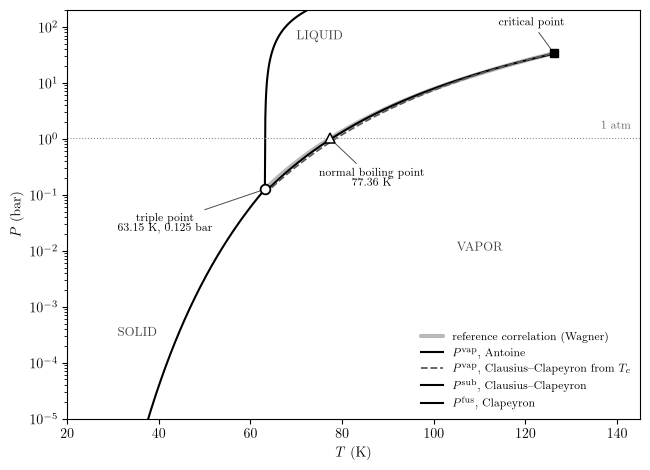

vaporization curve, against the Wagner reference:
  Antoine                     mean |error|  2.85%, worst 12.02%
  Clausius-Clapeyron from Tc  mean |error|  7.73%, worst 17.90%
    error at the critical point:   +0.30%   (anchored here, so ~0)
    error at the triple point:    -17.89%   (the far end)

The anchoring prediction holds. Fixing the curve at the critical point makes it exact
there and lets the error grow toward the triple point, where it reaches 18%. The
CO2 notebook anchored at the triple point and found the mirror image. Same equation,
same kind of error, opposite ends — the anchor decides which end you sacrifice, and
nothing decides that you get both.

The Antoine equation, with one more fitted constant and no thermodynamic content at
all, is 3 times better across the range.


In [8]:
from thermo.data import get_compound

# Reference vaporization curve: the Wagner correlation in the book's property database.
row = get_compound("nitrogen")
wa, wb, wc, wd = row["VpA"], row["VpB"], row["VpC"], row["VpD"]
Tc_db, Pc_db = float(row["Tc"]), float(row["Pc"])*BAR


def P_wagner(T):
    t = 1 - np.asarray(T, dtype=float)/Tc_db
    return Pc_db*np.exp((wa*t + wb*t**1.5 + wc*t**3 + wd*t**6)/(1 - t))


fig, ax = plt.subplots(figsize=(6.6, 4.8))

# --- reference vaporization curve, behind everything
T = np.linspace(T_triple, 0.99995*Tc_db, 400)
ax.plot(T, P_wagner(T)/BAR, "-", color="0.72", lw=3.0, solid_capstyle="round",
        label="reference correlation (Wagner)")

# --- vaporization, Antoine over its fitted range
T = np.linspace(T_Antoine_min, T_Antoine_max, 300)
ax.plot(T, P_antoine(A, B, C, T)/BAR, "-", color="black", lw=1.5,
        label=r"$P^\mathrm{vap}$, Antoine")

# --- vaporization, Clausius-Clapeyron anchored at the CRITICAL POINT
T = np.linspace(T_triple, Tc, 300)
ax.plot(T, P_CC(H_vap_1, Tc, Pc, T)/BAR, "--", color="0.35", lw=1.3,
        label=r"$P^\mathrm{vap}$, Clausius--Clapeyron from $T_c$")

# --- sublimation, Clausius-Clapeyron anchored at the triple point
T = np.linspace(24, T_triple, 300)
ax.plot(T, P_CC(H_sub_1, T_triple, P_triple, T)/BAR, "-", color="black", lw=1.5,
        label=r"$P^\mathrm{sub}$, Clausius--Clapeyron")

# --- melting, integrated Clapeyron from the triple point
T = np.linspace(T_triple, T_triple + 10, 100)
ax.plot(T, P_clapeyron(T_triple, P_triple, T, delta_fus_H, delta_fus_V)/BAR,
        "-", color="black", lw=1.5, label=r"$P^\mathrm{fus}$, Clapeyron")

# --- fixed points
ax.plot(T_triple, P_triple/BAR, "o", mfc="white", mec="black", ms=7, mew=1.3, zorder=5)
ax.plot(Tc, Pc/BAR, "s", color="black", ms=6, zorder=5)
ax.plot(T_boil, ATM/BAR, "^", mfc="white", mec="black", ms=7, mew=1.1, zorder=5)

ax.axhline(ATM/BAR, color="0.55", lw=0.8, ls=":")

ax.set_xlabel(r"$T$  (K)")
ax.set_ylabel(r"$P$  (bar)")
ax.set_yscale("log")
ax.set_xlim(20, 145)
ax.set_ylim(1e-5, 2e2)

LABEL_BOX = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85)
ax.annotate("triple point\n" rf"${T_triple}$ K, ${P_triple/BAR:.3f}$ bar",
            xy=(T_triple, P_triple/BAR), xytext=(-72, -30),
            textcoords="offset points", fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))
ax.annotate("critical point", xy=(Tc, Pc/BAR), xytext=(-16, 20),
            textcoords="offset points", fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))
ax.annotate(f"normal boiling point\n{T_boil} K", xy=(T_boil, ATM/BAR),
            xytext=(30, -34), textcoords="offset points", fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))
ax.text(143, ATM/BAR*1.5, "1 atm", fontsize=8, color="0.4", ha="right")

ax.text(31, 3e-4, "SOLID", fontsize=9, color="0.25")
ax.text(70, 6e1, "LIQUID", fontsize=9, color="0.25")
ax.text(105, 1e-2, "VAPOR", fontsize=9, color="0.25")

ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

# --- price the two approximate curves against the reference ----------------------
T_cmp = np.linspace(T_triple, 0.999*Tc, 300)
err_cc = 100*(P_CC(H_vap_1, Tc, Pc, T_cmp)/P_wagner(T_cmp) - 1)
err_an = 100*(P_antoine(A, B, C, T_cmp)/P_wagner(T_cmp) - 1)
print(f"vaporization curve, against the Wagner reference:")
print(f"  Antoine                     mean |error| {np.abs(err_an).mean():5.2f}%, "
      f"worst {np.abs(err_an).max():5.2f}%")
print(f"  Clausius-Clapeyron from Tc  mean |error| {np.abs(err_cc).mean():5.2f}%, "
      f"worst {np.abs(err_cc).max():5.2f}%")
print(f"    error at the critical point:  {err_cc[-1]:+6.2f}%   (anchored here, so ~0)")
print(f"    error at the triple point:    {err_cc[0]:+6.2f}%   (the far end)")

print(f"""
The anchoring prediction holds. Fixing the curve at the critical point makes it exact
there and lets the error grow toward the triple point, where it reaches {abs(err_cc[0]):.0f}%. The
CO2 notebook anchored at the triple point and found the mirror image. Same equation,
same kind of error, opposite ends — the anchor decides which end you sacrifice, and
nothing decides that you get both.

The Antoine equation, with one more fitted constant and no thermodynamic content at
all, is {np.abs(err_cc).mean()/np.abs(err_an).mean():.0f} times better across the range.""")

## What the second substance taught that the first could not

**Where the triple point sits relative to 1 atm decides how a substance behaves in a
laboratory.** Nitrogen's is at 0.125 bar, below atmospheric, so the 1 atm line crosses the
*vaporization* curve at 77.4 K and nitrogen is a pourable liquid. Carbon dioxide's is at
5.18 bar, above atmospheric, so the 1 atm line crosses the *sublimation* curve and dry ice never
melts. Two diagrams with identical topology and opposite everyday consequences, and the entire
difference is the position of one point.

**The anchor decides which end of a coexistence curve you sacrifice.** Anchoring
Clausius&ndash;Clapeyron at the critical point made the curve exact there and let the error grow
to the triple point; CO$_2$, anchored at the triple point, was the mirror image. Neither choice
is wrong and neither is better. The error is not a bad parameter to be tuned away: a single
constant $\Delta_\mathrm{vap}\underline H$ cannot describe a curve along which
$\Delta_\mathrm{vap}\underline H$ varies, so you choose where to be right.

**An exact rearrangement can be a numerically useless one.** That is the finding to carry
out of the notebook. Getting $\Delta_\mathrm{fus}\underline V$ by inverting the Clapeyron
equation between two points on the melting line is algebraically exact and needs no auxiliary
data &mdash; and it fails, badly, because it puts the entire answer at the mercy of a 0.15 K
temperature difference quoted to 0.1 K. The crude density estimate, with its 30% uncertainty and
its measurements at the wrong temperatures, is far better.

Nothing in the algebra announces this. The way you catch it is the way it was caught here: get
the answer twice, by different routes, and when they disagree ask which input each one is
leaning on. Then check the sensitivity explicitly. *Conditioning is a property of the formula,
not of the physics* &mdash; and eliminating an assumption often just relocates your uncertainty
onto whichever number can least afford to carry it.

**And an extrapolation that is still outstanding.** The sublimation curve uses
$\Delta_\mathrm{sub}\underline H = 7.34$ kJ/mol, measured over 23&ndash;27.5 K, from 24 K up to
the 63 K triple point. Nothing above checks it, because no reference correlation for solid
nitrogen was to hand. Treat that curve as the least trustworthy line on the plot &mdash; and
notice that it looks exactly as convincing as the others.

### Things to try

1. **Find a better 1 atm melting temperature for nitrogen** and redo method 1 with it. How many
   significant figures do you need before the answer stabilizes to within 10%? Compare with the
   number of figures Streng reports.

2. **Test the conditioning argument on CO$_2$.** Its triple point is at 5.18 bar, so 1 atm lies
   *below* it and there is no normal melting point to invert from &mdash; but there is a
   published melting curve. Pick two points on it several tens of kelvin apart and invert
   Clapeyron between them. Does the method work when the interval is wide? What does that say
   about when the inversion is legitimate?

3. **Check the sublimation extrapolation.** Estimate
   $\Delta_\mathrm{sub}\underline H \approx \Delta_\mathrm{fus}\underline H
   + \Delta_\mathrm{vap}\underline H$ at the triple point from the values in this notebook and
   compare with the 7.34 kJ/mol used. Which is more trustworthy near 63 K, and why is the
   additivity estimate valid there and nowhere else?

4. **Nitrogen's melting line has a positive slope; water's is negative.** Both are computed from
   the same equation. Which quantity carries the sign, what is its sign for each substance, and
   what does that predict about skating on ice versus skating on solid nitrogen?

5. **Do a third substance and predict before you compute.** Argon: $T_t = 83.8$ K at 0.689 bar,
   $T_c = 150.7$ K at 48.6 bar, normal boiling point 87.3 K. Will argon have a liquid range at
   1 atm? Then check.

6. **`mechanical_stability_CO2.ipynb`** goes after the same coexistence curve from the other
   direction &mdash; from an equation of state rather than from measured coexistence data.
   Compare what each approach needs as input and what each gives you for free.